<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Training a segmentation model from scratch

In [2]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

--2026-09-02 19:38:32--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2026-09-02 19:38:34--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-09-02 19:38:34--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

In [3]:
import pathlib

input_dir = pathlib.Path("images")
target_dir = pathlib.Path("annotations/trimaps")

input_img_paths = sorted(input_dir.glob("*.jpg"))

# Ignores some spurious files in the trimaps directory that start with a "."
target_paths = sorted(target_dir.glob("[!.]*.png"))

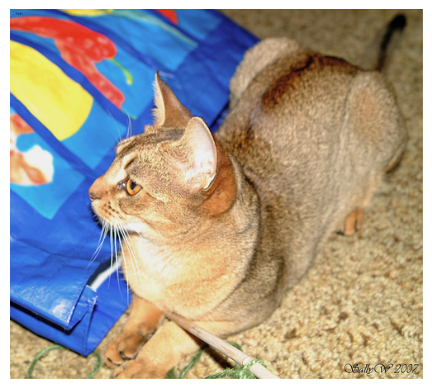

In [4]:
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array, array_to_img

plt.axis("off")

# Displays input image number 9
plt.imshow(load_img(input_img_paths[9]))

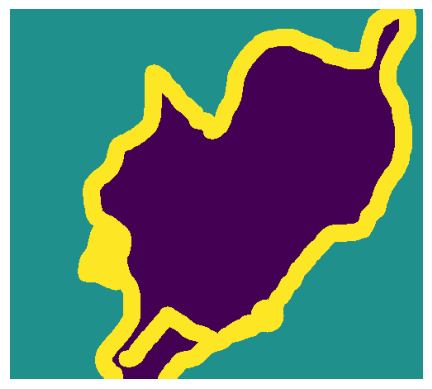

In [5]:
def display_target(target_array):
    # The original labels are 1, 2, and 3. We subtract 1 so that the
    # labels range from 0 to 2, and then we multiply by 127 so that the
    # labels become 0 (black), 127 (gray), 254 (near-white).
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

# We use color_mode='grayscale' so that the image we load is treated as
# having a single color channel.
img = img_to_array(load_img(target_paths[9], color_mode="grayscale"))
display_target(img)

In [6]:
import numpy as np
import random

# We resize everything to 200 x 200 for this example.
img_size = (200, 200)

# Total number of samples in the data
num_imgs = len(input_img_paths)

# Shuffles the file paths (they were originall sorted by breed).
# We use the same seed (1337) in both statements to ensure that the input
# paths and target paths stay in the same order.
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale")
    )

    # Subtracts 1 so that our labels become 0, 1, and 2
    img = img.astype("uint8") - 1

    return img

# Loads all images in the input_imgs float32 array and their masks in
# the targets uint8 array (same order). The inputs have three channels
# (RBG values), and the targets have a single channel (which contains integer labels).
input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

In [7]:
# Split the arrays into a training and a validation set.
# Reserves 1000 samples for validation
num_val_samples = 1000

# Splits the data into a training and a validation set
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]

val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

In [8]:
# Building and training the segmentation model
import keras
from keras.layers import Rescaling, Conv2D, Conv2DTranspose

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))

    # Don't forget to rescale input images to the [0-1] range.
    x = Rescaling(1.0 / 255)(inputs)

    # We use padding="same" everywhere to avoid the influence of border
    # padding on feature map size.
    x = Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(64, 3, activation="relu", padding="same")(x)

    x = Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(128, 3, activation="relu", padding="same")(x)

    x = Conv2D(256, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(256, 3, activation="relu", padding="same")(x)

    x = Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)

    x = Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)

    x = Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)

    # We end the model with a per-pixel three-way softmax to classify
    # each output pixel into one of our three categories
    outputs = Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    return keras.Model(inputs, outputs)

model = get_model(img_size=img_size, num_classes=3)

In [9]:
# Use a metric named Intersection over Union (IoU)
foreground_iou = keras.metrics.IoU(
    # Specifies the total number of classes
    num_classes=3,

    # Specifies the class to compute IoU for (0 = foreground)
    target_class_ids=(0,),
    name="foreground_iou",

    # Our targets are sparse (integer class IDs).
    sparse_y_true=True,

    # But our model's predictions are a dense softmax!
    sparse_y_pred=False,
)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "oxford_segementation.keras",
        save_best_only=True,
    ),
]

history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=50,
    callbacks=callbacks,
    batch_size=64,
    validation_data=(val_input_imgs, val_targets),
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - foreground_iou: 0.1244 - loss: 0.9056 - val_foreground_iou: 0.4514 - val_loss: 0.7880
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 537ms/step - foreground_iou: 0.4673 - loss: 0.7436 - val_foreground_iou: 0.4897 - val_loss: 0.6688
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 536ms/step - foreground_iou: 0.5123 - loss: 0.6434 - val_foreground_iou: 0.5528 - val_loss: 0.6013
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 538ms/step - foreground_iou: 0.5723 - loss: 0.5623 - val_foreground_iou: 0.5938 - val_loss: 0.5228
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 537ms/step - foreground_iou: 0.6239 - loss: 0.4994 - val_foreground_iou: 0.6412 - val_loss: 0.4803
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 535ms/step - foreground_iou: 0.6424 - loss: 0.4745 - val_foreground_iou: 0.6501 - val_loss: 0.4804
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 538ms/step - foreground_iou: 0.6656 - loss: 0.4459 - val_foreground_iou: 0.6382 - val_loss: 0.4630
E

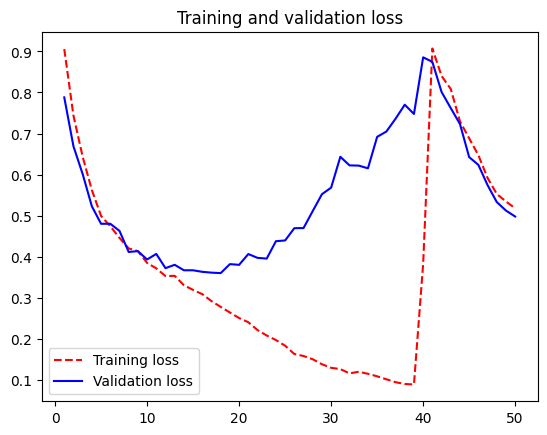

In [13]:
epochs = range(1, len(history.history["loss"]) + 1)

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


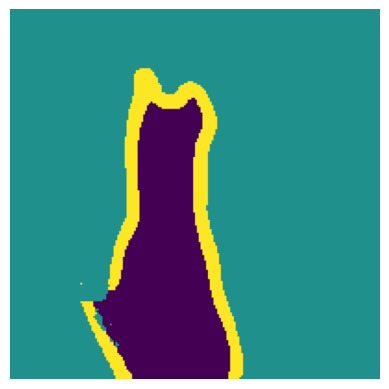

In [15]:
model = keras.models.load_model("oxford_segementation.keras")

i = 4
test_image = val_input_imgs[i]
plt.axis("off")
plt.imshow(array_to_img(test_image))

mask = model.predict(np.expand_dims(test_image, 0))[0]

# Utility to display a model's prediction
def display_mask(pred):
    mask = np.argmax(pred, axis=-1)
    mask *= 127
    plt.axis("off")
    plt.imshow(mask)

display_mask(mask)

In [16]:
# Using a pretrained segmentation model

In [17]:
import keras_hub

model = keras_hub.models.ImageSegmenter.from_preset("sam_huge_sa1b")

100%|██████████| 3.06k/3.06k [00:00<00:00, 2.45MB/s]


100%|██████████| 5.77k/5.77k [00:00<00:00, 11.8MB/s]


100%|██████████| 2.39G/2.39G [02:41<00:00, 15.9MB/s]


100%|██████████| 2.39G/2.39G [02:49<00:00, 15.1MB/s]


In [18]:
model.count_params()

641090864

259153/259153 ━━━━━━━━━━━━━━━━━━━━ 1s 3us/step


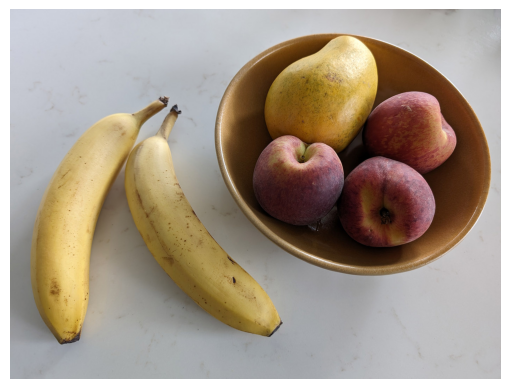

In [19]:
# Downloads the image and returns the local file path
path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)

# Loads the image as a Python Imaging Library (PIL) object
pil_image = keras.utils.load_img(path)

# Turns the PIL object into a NumPy matrix
image_array = keras.utils.img_to_array(pil_image)

# Displays the NumPy matrix
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()

In [21]:
from keras import ops

image_size = (1024, 1024)

def resize_and_pad(x):
    return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)

image = resize_and_pad(image_array)

In [29]:
import matplotlib.pyplot as plt
from keras import ops

def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

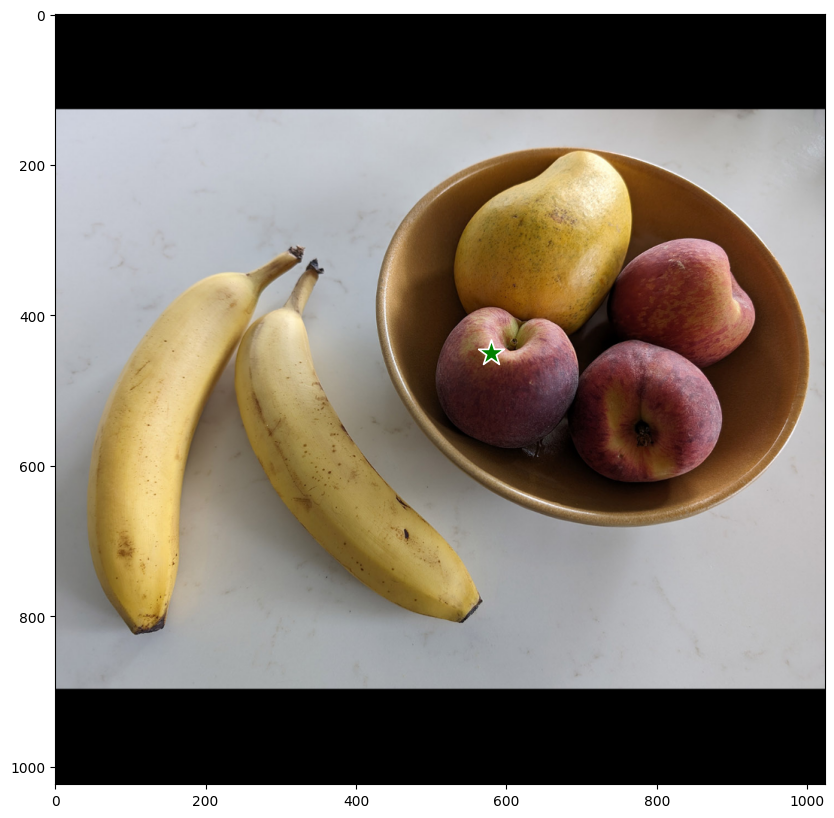

In [24]:
import numpy as np

# Coordinates of our point
input_point = np.array([[580, 450]])

# 1 means foreground, and 0 means background.
input_label = np.array([1])

plt.figure(figsize=(10, 10))

# "gca" means "get current axis" - the current figure.
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

In [26]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step


In [27]:
outputs["masks"].shape

(1, 4, 256, 256)

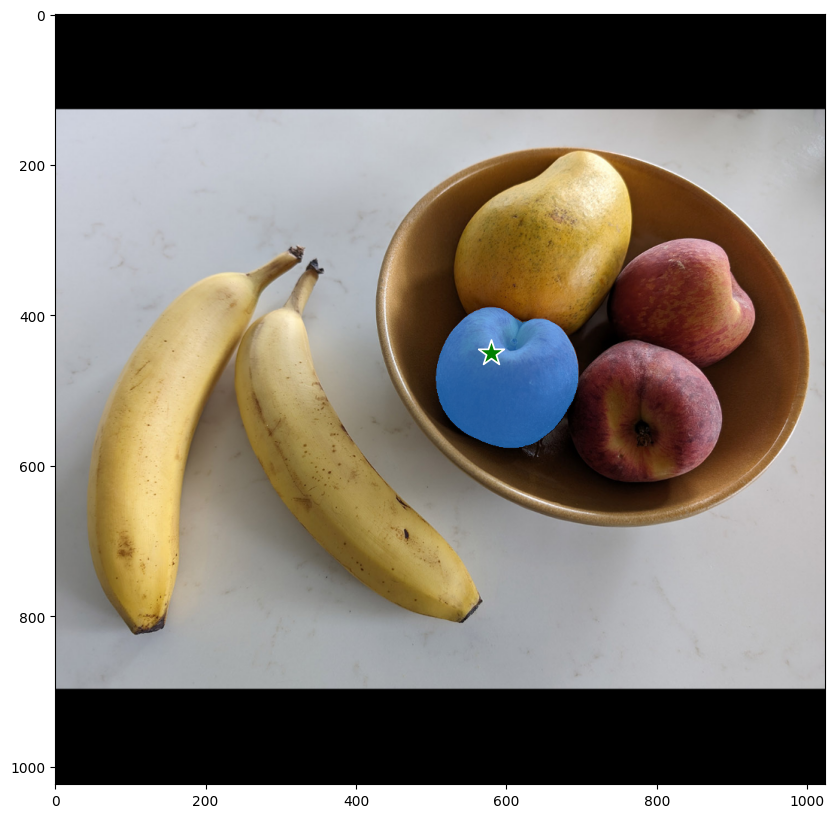

In [30]:
def get_mask(sam_outputs, index=0):
    mask = sam_outputs["masks"][0][index]
    mask = np.expand_dims(mask, axis=-1)
    mask = resize_and_pad(mask)

    return ops.convert_to_numpy(mask) > 0.0

mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

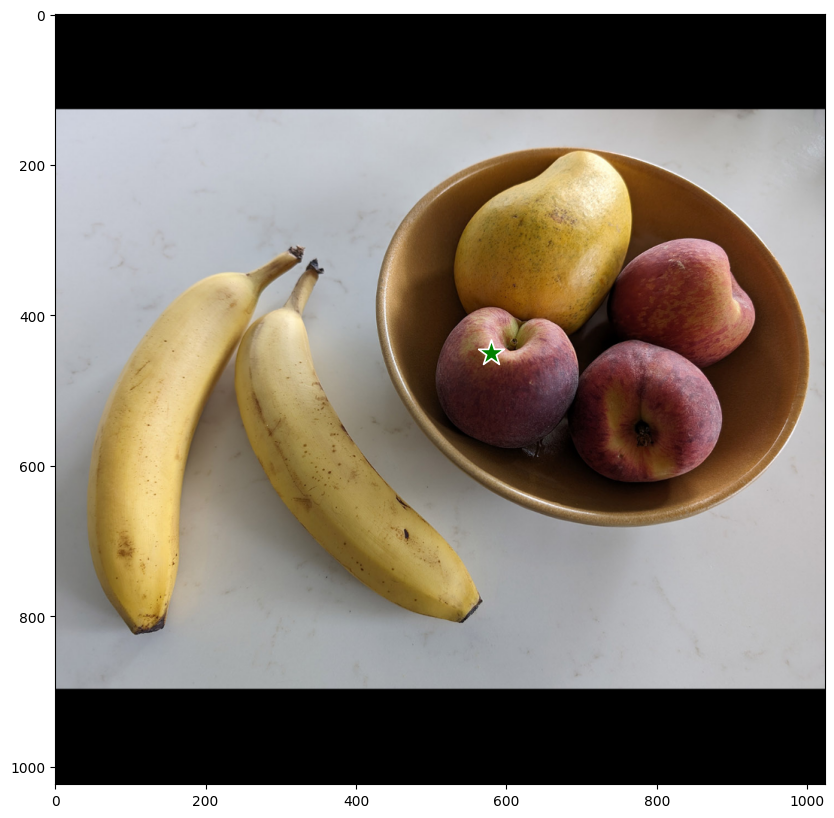

In [32]:
import numpy as np

# Coordinates of our point
input_point = np.array([[580, 450]])

# 1 means foreground, and 0 means background.
input_label = np.array([1])

plt.figure(figsize=(10, 10))

# "gca" means "get current axis" - the current figure.
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

In [33]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0)
    }
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [34]:
outputs["masks"].shape

(1, 4, 256, 256)

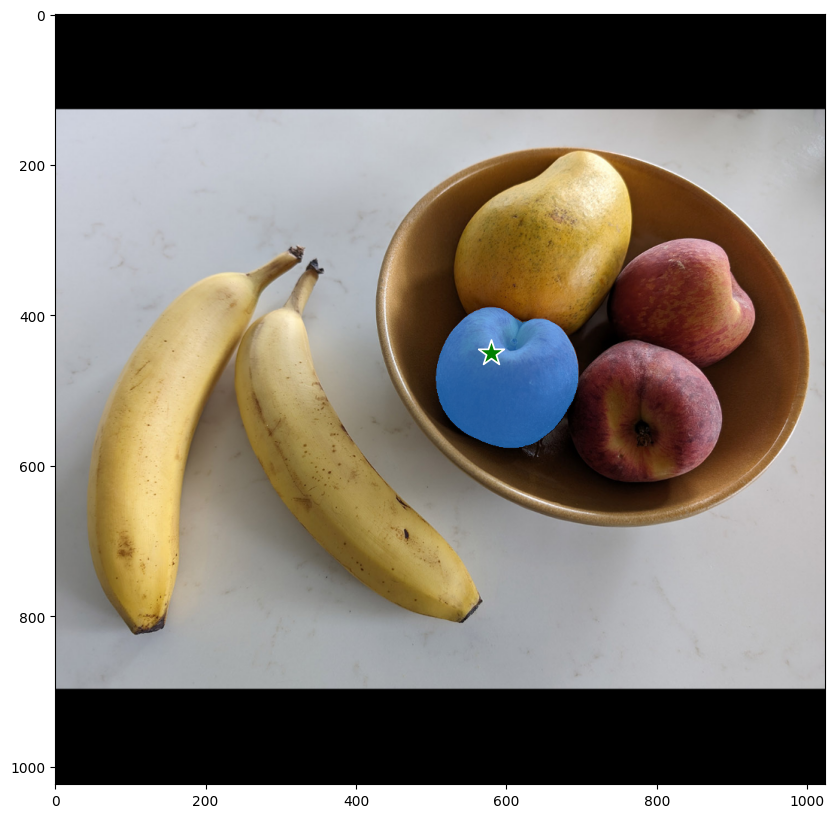

In [35]:
def get_mask(sam_outputs, index=0):
    mask = sam_outputs["masks"][0][index]
    mask = np.expand_dims(mask, axis=-1)
    mask = resize_and_pad(mask)

    return ops.convert_to_numpy(mask) > 0.0

mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))

show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


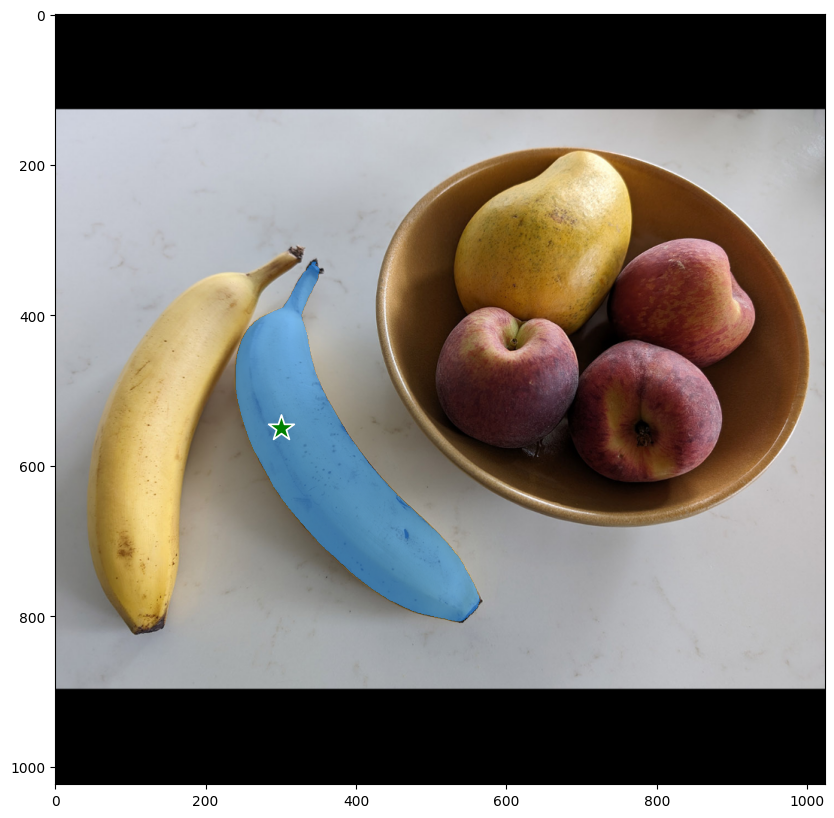

In [36]:
input_point = np.array([[300, 550]])
input_label = np.array([1])

outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)

mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))

show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())

plt.show()

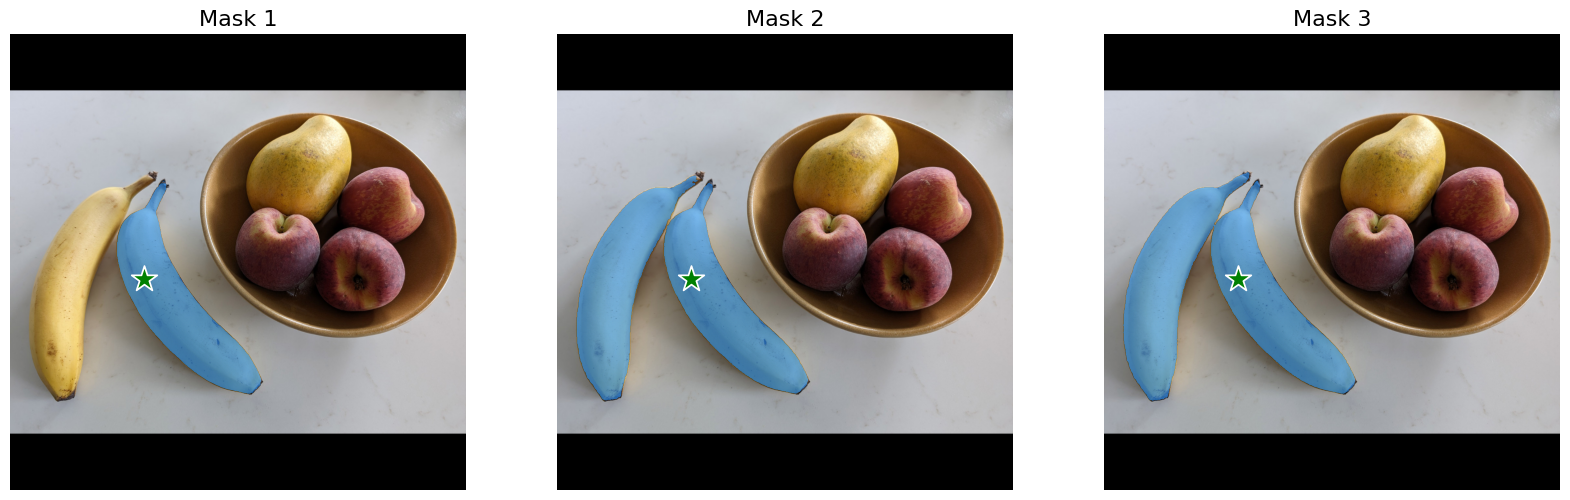

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 60))
masks = outputs["masks"][0][1:]

for i, mask in enumerate(masks):
    show_image(image, axes[i])
    show_points(input_point, axes[i])

    mask = get_mask(outputs, index=i + 1)

    show_mask(mask, axes[i])

    axes[i].set_title(f"Mask {i + 1}", fontsize=16)
    axes[i].axis("off")

plt.show()

In [38]:
# Prompting the model with a target box

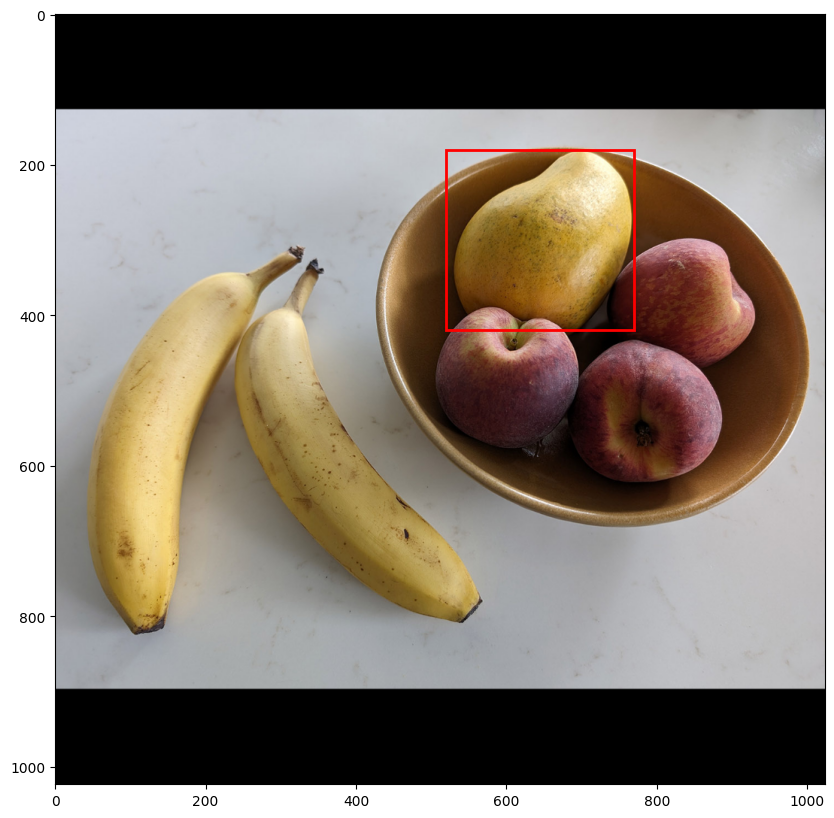

In [39]:
input_box = np.array(
    [
        # Top-left corner
        [520, 180],

        # Bottom-right corner
        [770, 420],
    ]
)

plt.figure(figsize=(10, 10))

show_image(image, plt.gca())
show_box(input_box, plt.gca())

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


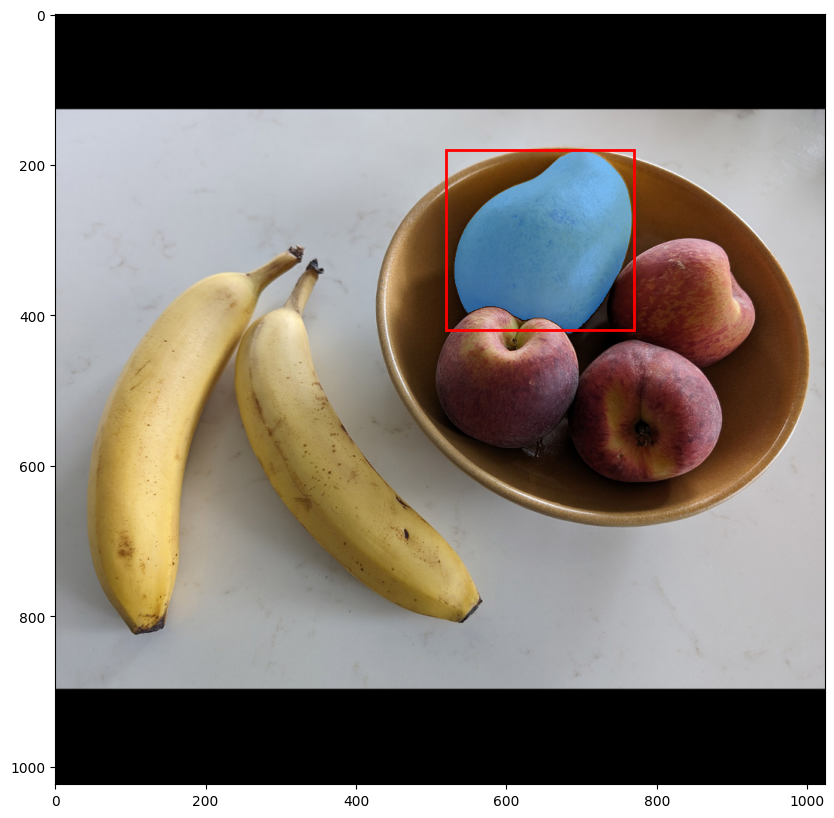

In [40]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "boxes": ops.expand_dims(input_box, axis=(0, 1)),
    }
)

mask = get_mask(outputs, 0)

plt.figure(figsize=(10, 10))

show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_box(input_box, plt.gca())

plt.show()